In [2]:
import os
import shutil

# 1. Define Project Structure
project_name = "Customer_Segmentation_Project"
subfolders = ['data', 'visualizations', 'models', 'reports']

# 2. Create Folders
if not os.path.exists(project_name):
    os.makedirs(project_name)
    for folder in subfolders:
        os.makedirs(os.path.join(project_name, folder))
    print(f"Project structure created: {project_name}")

# 3. AUTOMATED FIX: Look in Downloads and move to Project Data folder
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
possible_names = ['Mall_Customers.csv', 'Customer_Data.csv']
target_path = os.path.join(project_name, 'data', 'Customer_Data.csv')

# Search for the file in Downloads first
file_found = False
for name in possible_names:
    source_path = os.path.join(downloads_path, name)
    if os.path.exists(source_path):
        shutil.move(source_path, target_path)
        print(f"Successfully found '{name}' in Downloads and moved to '{target_path}'")
        file_found = True
        break

# If not in downloads, check the current directory
if not file_found:
    for name in possible_names:
        if os.path.exists(name):
            shutil.move(name, target_path)
            print(f"Successfully found '{name}' in current folder and moved to '{target_path}'")
            file_found = True
            break

if not file_found:
    if os.path.exists(target_path):
        print(f"File already exists in: {target_path}")
    else:
        print(f"ALERT: Could not find the file in Downloads or current folder.")
        print(f"Please make sure the file is named 'Mall_Customers.csv' in your Downloads.")

Successfully found 'Mall_Customers.csv' in Downloads and moved to 'Customer_Segmentation_Project\data\Customer_Data.csv'


## step 1- Import Libraries

In [4]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ["OMP_NUM_THREADS"] = "1" # Solves KMeans memory leak on Windows

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib

print('Libraries imported successfully!')

Libraries imported successfully!


## step 2- Load Data

In [5]:
# The path now matches the professional structure
df = pd.read_csv('Customer_Segmentation_Project/data/Customer_Data.csv')
print(f"Dataset Loaded: {len(df)} records.")
df.head()

Dataset Loaded: 200 records.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## step 3- EDA & Preprocessing

In [6]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Feature selection (Annual Income and Spending Score)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling - Required for KMeans stability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data scaled and ready for clustering.")

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Data scaled and ready for clustering.


## Step 4- Model Training (K Selection & Clustering)

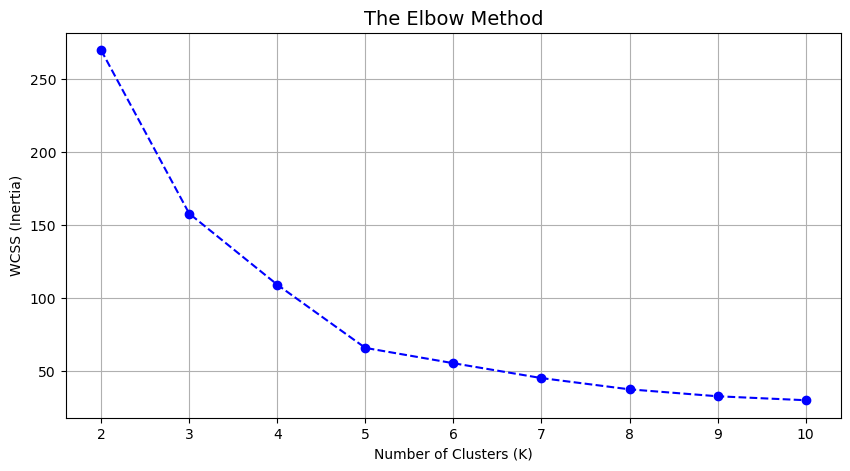

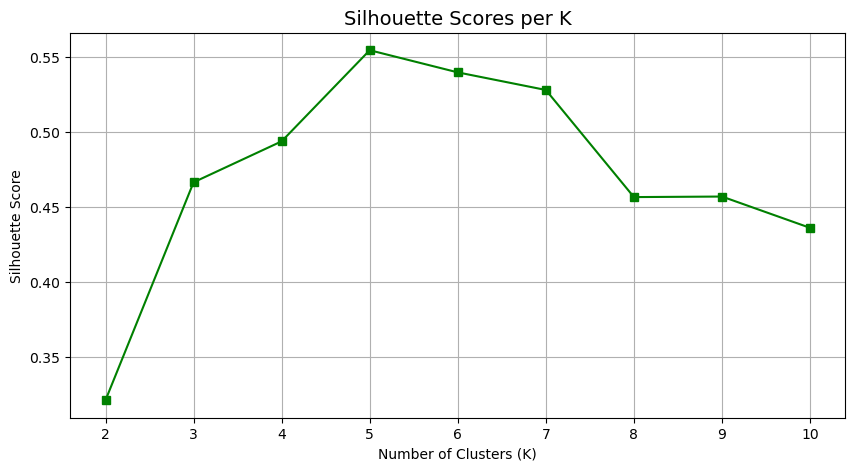

Both validation visuals have been saved to the visualizations folder.


In [10]:
## 4.1- Model Validation (Elbow Method & Silhouette Scores)
from sklearn.metrics import silhouette_score

# 1. Calculate metrics for K = 2 to 10
wcss = []
silhouette_avg = []
k_range = range(2, 11)

for i in k_range:
    # Using parameters from Appendix A of your report (n_init=20, random_state=42)
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=20, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))

# --- STEP A: THE ELBOW METHOD ---
plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='o', color='blue', linestyle='--')
plt.title('The Elbow Method', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)

# Save Elbow Plot
plt.savefig('Customer_Segmentation_Project/visualizations/01_elbow_method.png')
plt.show()

# --- STEP B: SILHOUETTE SCORES ---
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_avg, marker='s', color='green', linestyle='-')
plt.title('Silhouette Scores per K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

# Save Silhouette Plot
plt.savefig('Customer_Segmentation_Project/visualizations/02_silhouette_scores.png')
plt.show()

print("Both validation visuals have been saved to the visualizations folder.")

## Step 5- Visualizing Results

Elbow plot saved to visualizations/elbow_plot.png


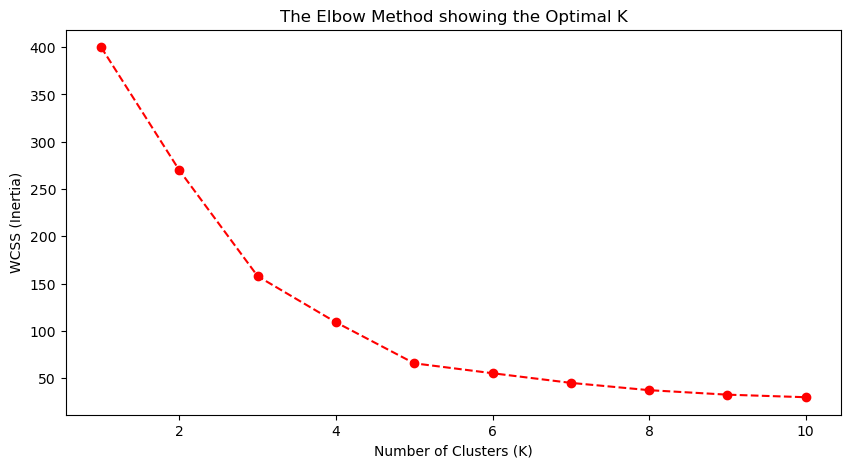

In [12]:
## 5- Model Training (K Selection & Clustering)

# 5.1 The Elbow Method Visualization
wcss = []
for i in range(1, 11):
    # Parameters from Appendix A of your report (n_init=20, random_state=42)
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=20, random_state=42) 
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red')
plt.title('The Elbow Method showing the Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')

# SAVE the visualization to your project folder
plt.savefig('Customer_Segmentation_Project/visualizations/elbow_plot.png')
print("Elbow plot saved to visualizations/elbow_plot.png")
plt.show()

# 5.2 Training the Final Model (K=5)
# After seeing the elbow at 5, we train the final model as per your report
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=20, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

Plot saved to: Customer_Segmentation_Project/visualizations/final_clusters.png


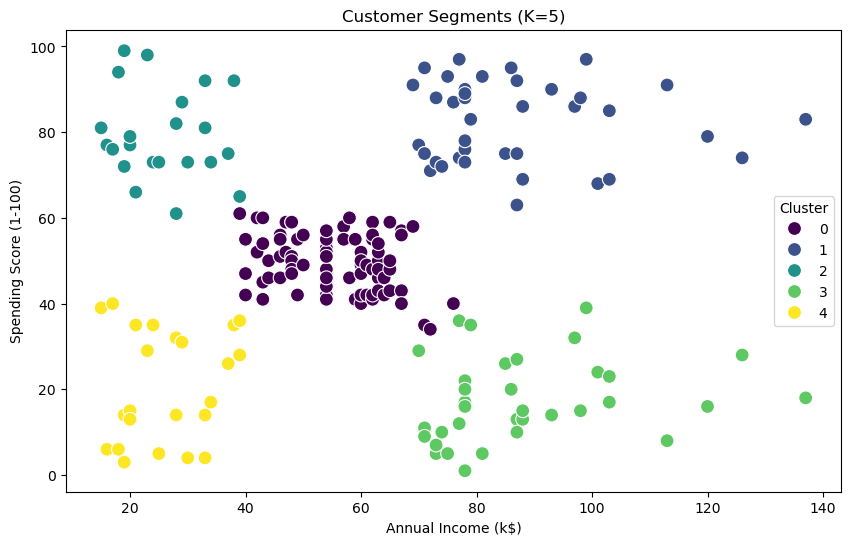

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='viridis', data=df, s=100)
plt.title('Customer Segments (K=5)')

# SAVE the visual before showing it
plot_path = 'Customer_Segmentation_Project/visualizations/final_clusters.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")

plt.show()